In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
try:
    from xgboost import XGBRegressor
except Exception as exc:  # pragma: no cover - environment dependent
    # Silently setting this to None meant XGBoost was dropped from every model
    # comparison without a word, and the bar simply never appeared in the figure.
    # On macOS the usual cause is a missing OpenMP runtime: `brew install libomp`.
    XGBRegressor = None
    warnings.warn(
        f"XGBoost unavailable, model comparison will omit it: {exc}",
        RuntimeWarning,
        stacklevel=2,
    )
    print("!! XGBoost NOT available - comparison figures will be missing that model.")

sys.path.append(str(Path("../scripts").resolve()))

from paper_figure_utils import (
    OUTCOME_DISPLAY,
    GRID,
    MUTED,
    PAPER_BG,
    load_all_coefs,
    plot_charger_subtype_comparison,
    plot_dot_whisker_from_csvs,
    plot_heatmap_from_csvs,
    plot_stability_from_csvs,
    sync_site_figure,
    apply_paper_style,
    _finish_figure as finish_figure,
)
from build_site_index_assets import (
    derive_analysis_frame,
    build_geography_panel,
    build_eda_panel,
    build_income_small_multiples,
    build_predictor_lowess_small_multiples,
    build_coefficient_path,
)

ROOT = Path("..").resolve()
TAB_DIR = ROOT / "outputs" / "standardized_tables"
FIG_DIR = ROOT / "outputs" / "standardized_figures"
SITE_FIG_DIR = ROOT / "site" / "assets" / "figures"
OUTPUT_FIG_DIR = ROOT / "outputs" / "figures"

PAPER_MAIN_MODELS = {
    "y_pv": "Model 1 baseline (climate controls)",
    "y_chargers": "Model 1 baseline (climate controls)",
    "y_storage": "Model 1 baseline (climate controls)",
    "y_wind_mw": "Model 1 baseline (climate controls)",
}

PAPER_ROBUSTNESS_MODELS = [
    "Model 1 baseline (climate controls)",
    "Model 2 (add bachelors)",
    "Model 2 (add housing value)",
    "Model 2C (add housing structure)",
    "Model 4 interactions (centered)",
    "Model 5C clustered SEs by county",
    "Model 7 (infrastructure controls, outcome-safe)",
    "Model 8 add demand proxy",
]

TERMS_MAIN = [
    "log_median_household_income",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "poverty_rate",
]

HEATMAP_OUTCOMES = ["y_pv", "y_chargers", "y_storage", "y_wind_mw"]
HEATMAP_MODELS = ["Model 1 baseline (climate controls)"]
TERMS_HEATMAP = TERMS_MAIN

ROBUSTNESS_TERMS_BY_OUTCOME = {
    "y_pv": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "pct_single_family_units",
        "pct_multifamily_units",
        "pct_mobile_home_units",
        "ghi_mean_kwh_m2_day_2023",
    ],
    "y_chargers": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "pct_single_family_units",
        "pct_multifamily_units",
        "pct_mobile_home_units",
        "cdd65_2023",
        "hdd65_2023",
    ],
    "y_storage": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "pct_single_family_units",
        "pct_multifamily_units",
        "pct_mobile_home_units",
        "cdd65_2023",
        "hdd65_2023",
    ],
    "y_wind_mw": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "pct_single_family_units",
        "pct_multifamily_units",
        "pct_mobile_home_units",
        "wind_ws50m_mean_2023",
    ],
}



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.11/site-p

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.11/site-p

AttributeError: _ARRAY_API not found

Regenerated standardized coefficient figures:
outputs/standardized_figures/baseline_der_outcomes_dot_whisker.png
outputs/standardized_figures/y_pv_robustness.png
outputs/standardized_figures/y_chargers_robustness.png
outputs/standardized_figures/y_storage_robustness.png
outputs/standardized_figures/y_wind_mw_robustness.png
outputs/standardized_figures/coef_heatmap_appendix.png
outputs/standardized_figures/charger_subtype_comparison.png


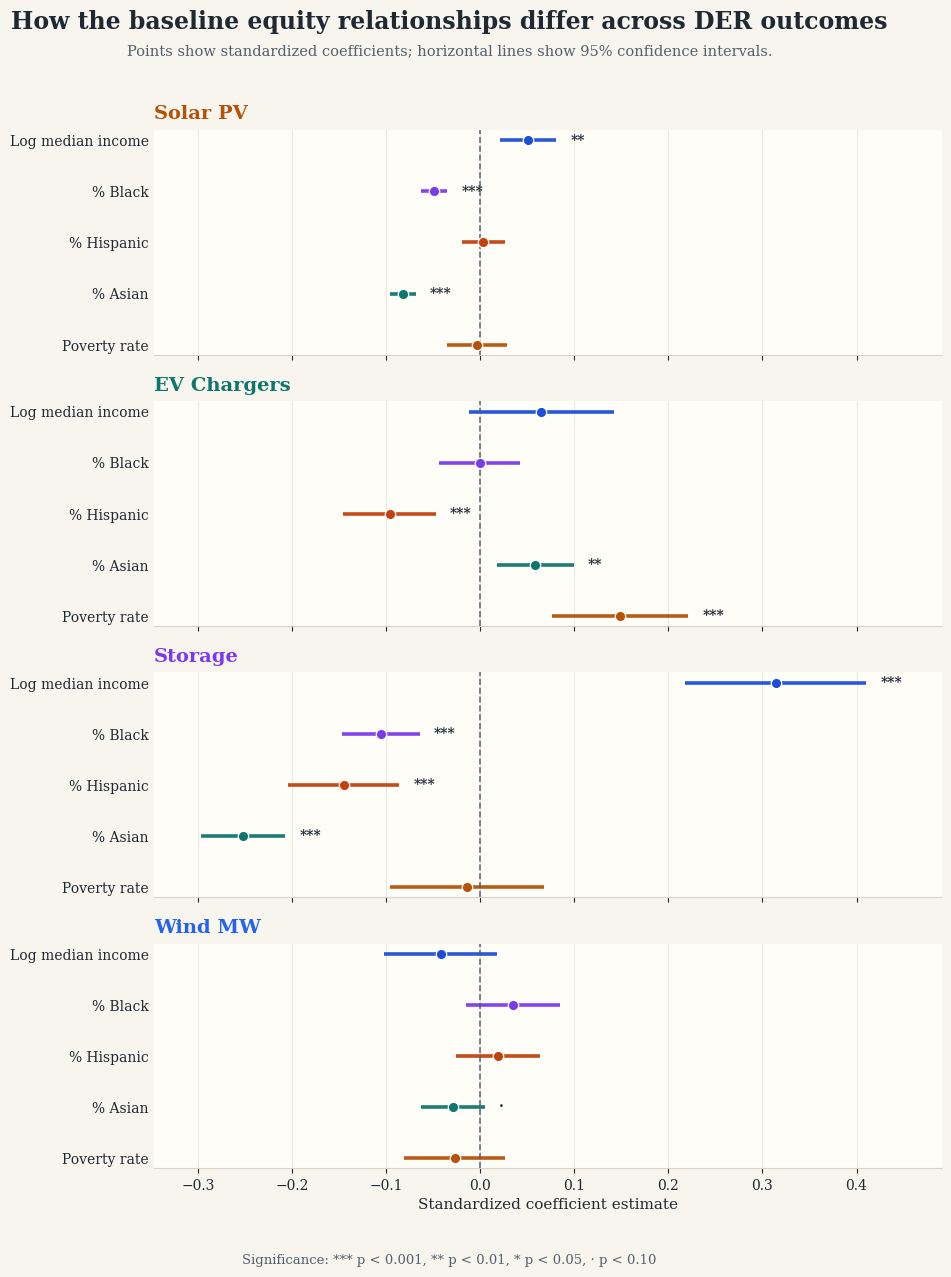

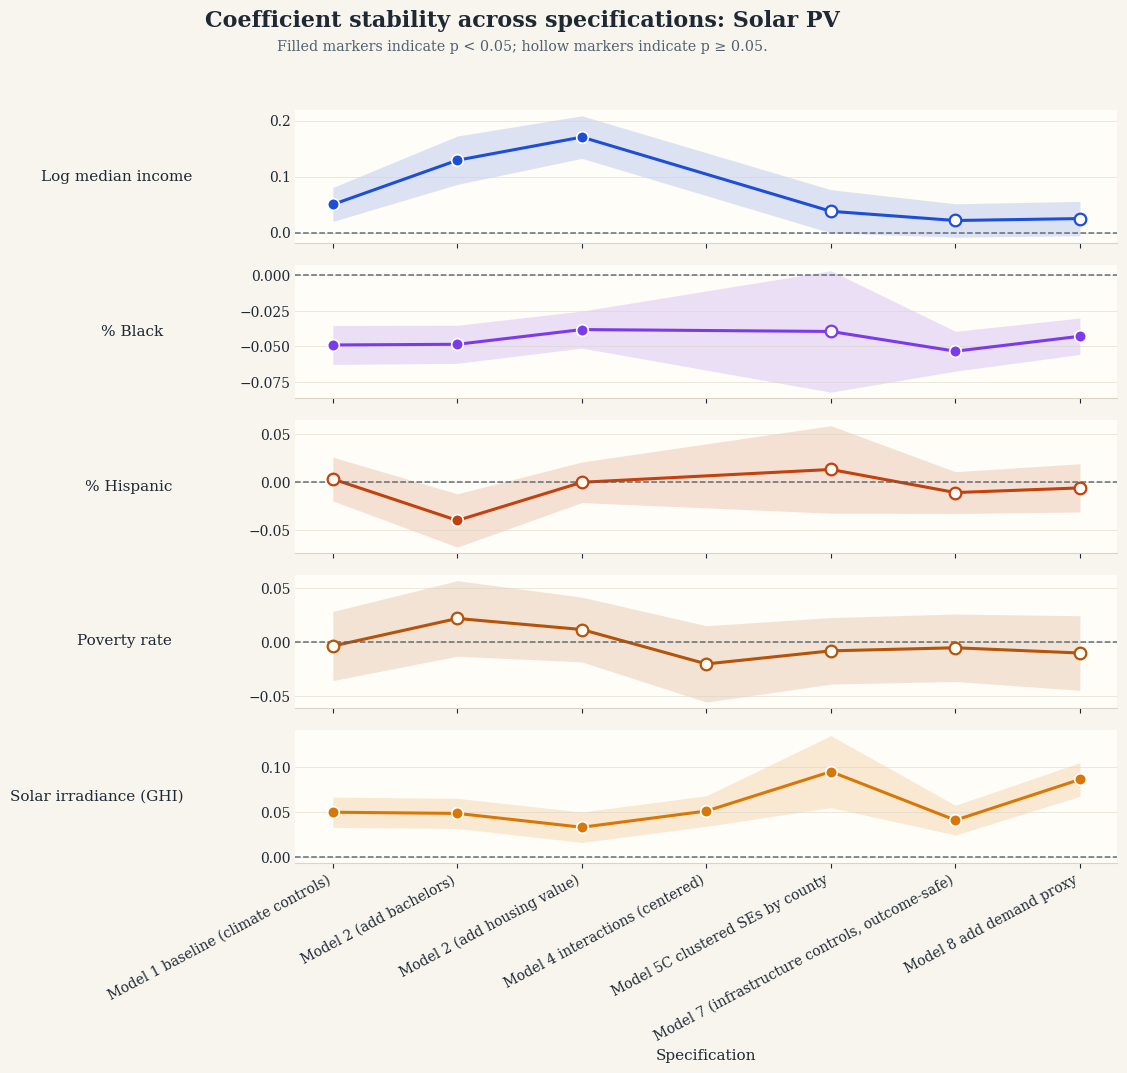

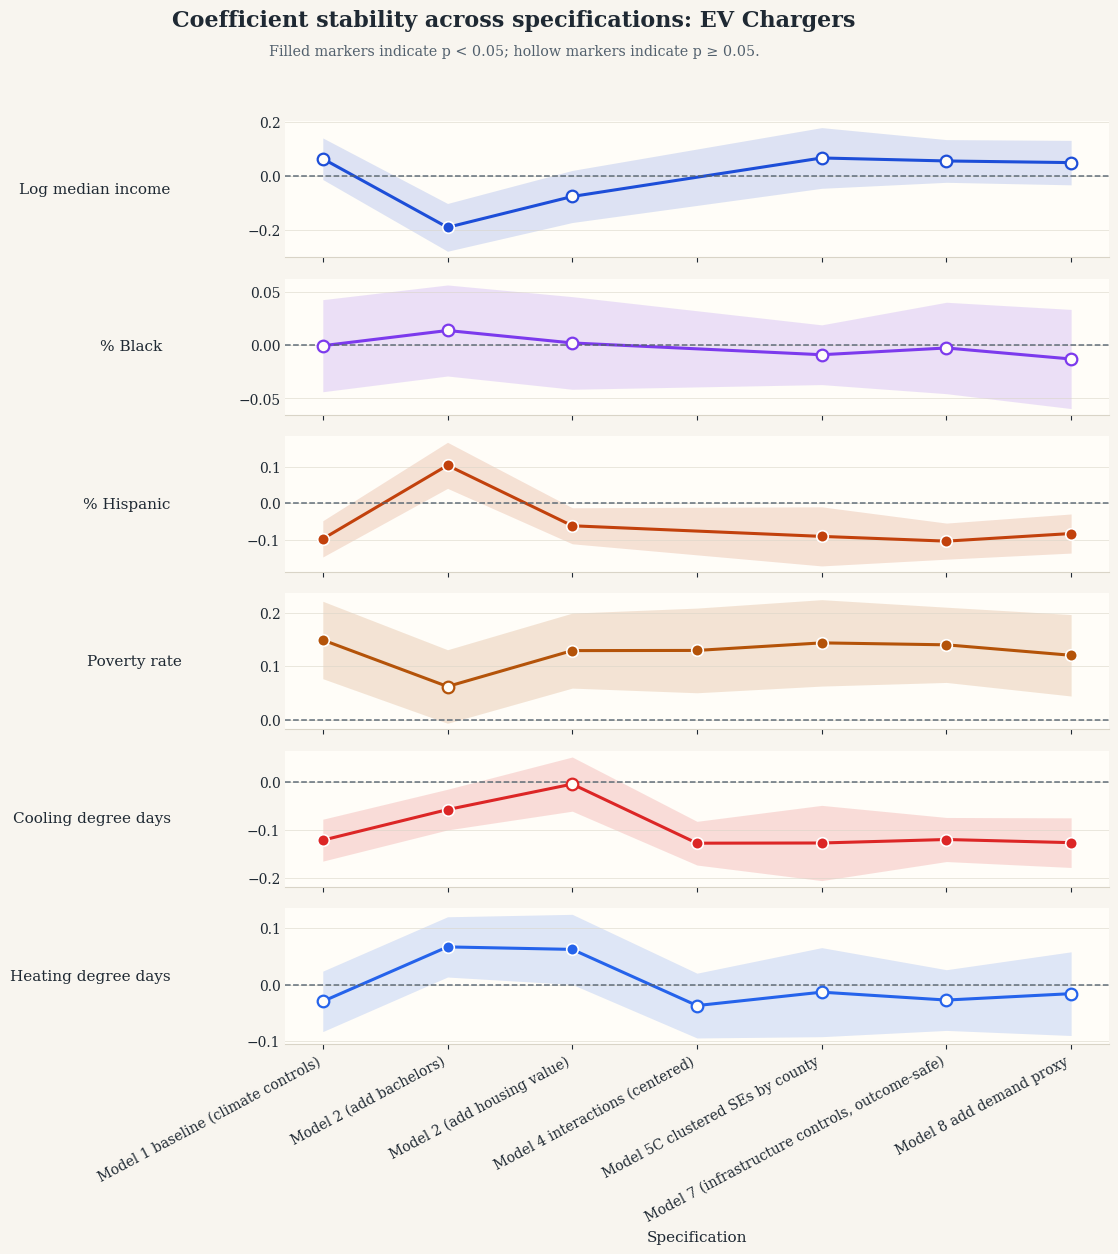

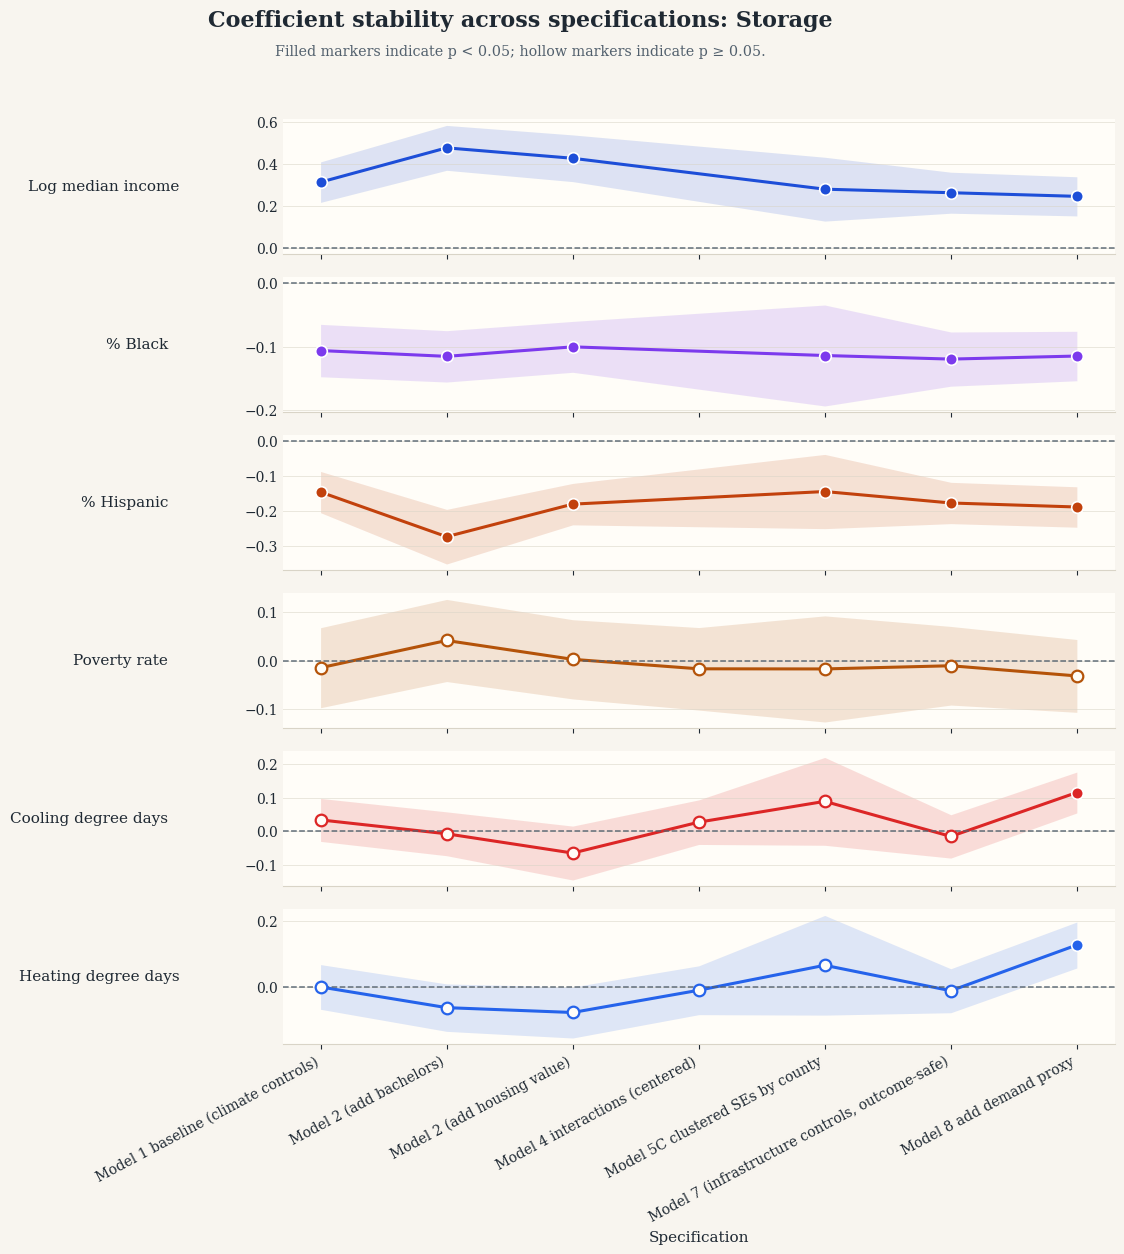

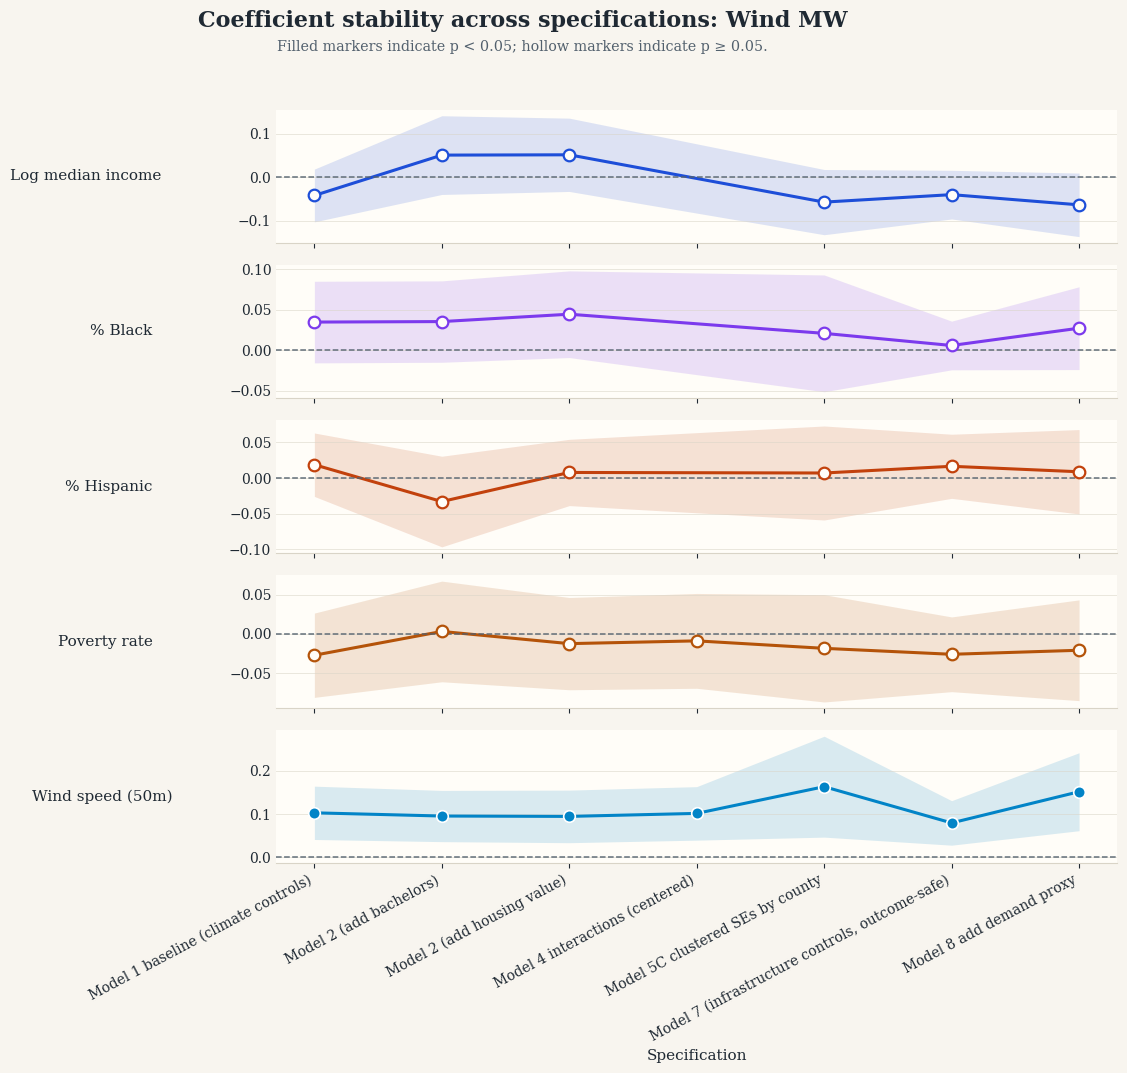

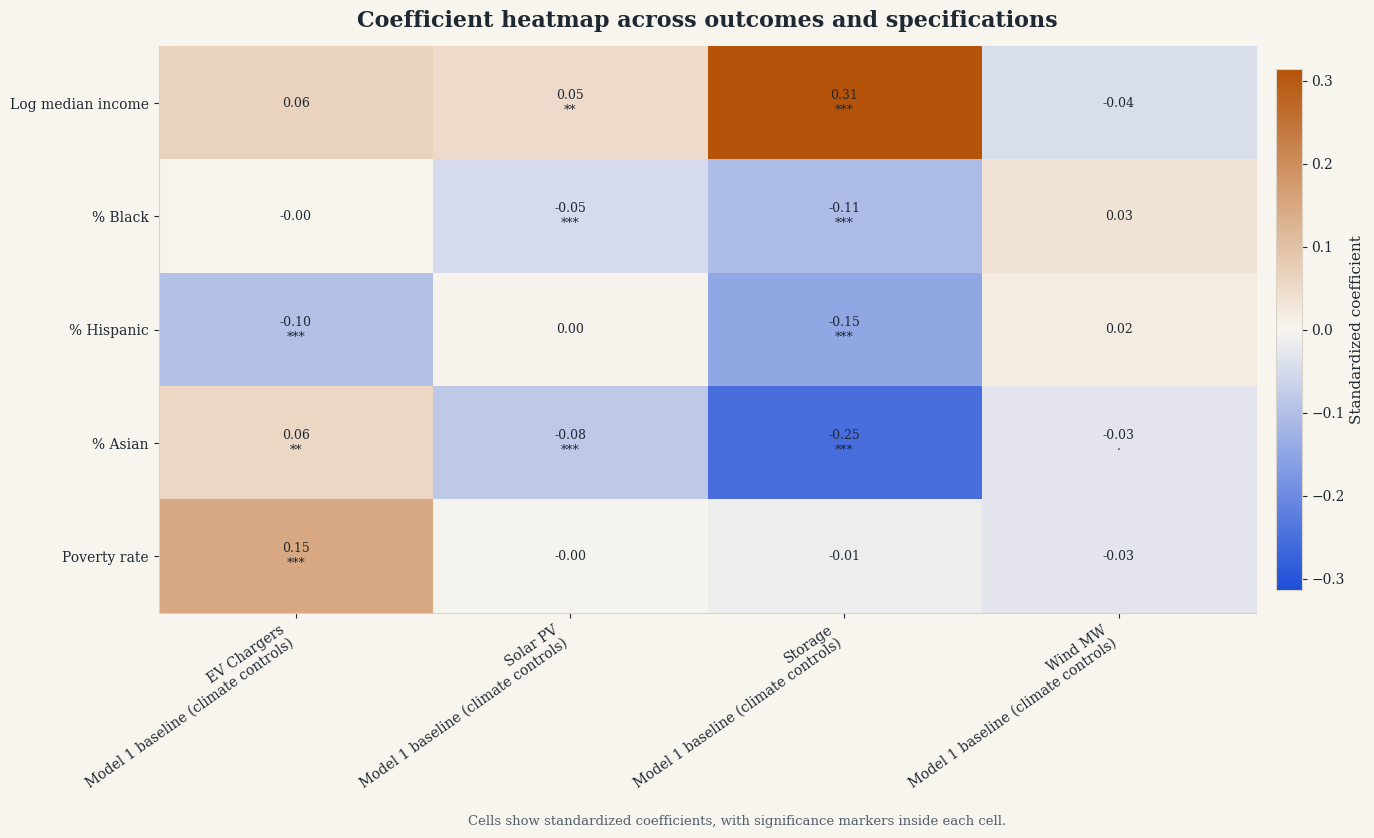

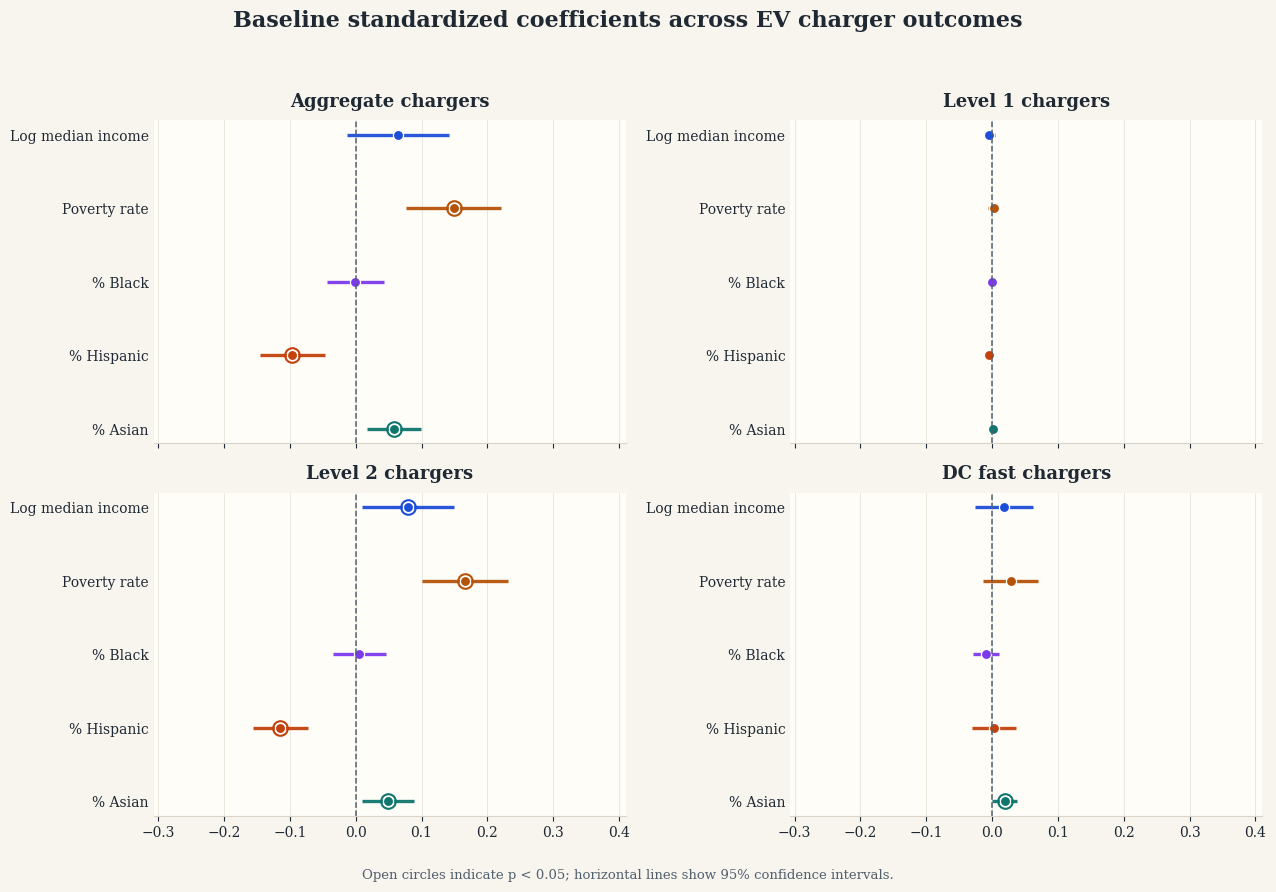

In [2]:
all_coefs = load_all_coefs(TAB_DIR)

generated = []

dot_whisker_path = FIG_DIR / "baseline_der_outcomes_dot_whisker.png"
plot_dot_whisker_from_csvs(
    all_coefs=all_coefs,
    main_models=PAPER_MAIN_MODELS,
    terms_keep=TERMS_MAIN,
    outcome_display=OUTCOME_DISPLAY,
    save_path=dot_whisker_path,
)
generated.append(dot_whisker_path)

for outcome in HEATMAP_OUTCOMES:
    save_path = FIG_DIR / f"{outcome}_robustness.png"
    plot_stability_from_csvs(
        all_coefs=all_coefs,
        outcome=outcome,
        models_keep=PAPER_ROBUSTNESS_MODELS,
        terms_keep=ROBUSTNESS_TERMS_BY_OUTCOME[outcome],
        outcome_display=OUTCOME_DISPLAY,
        save_path=save_path,
    )
    generated.append(save_path)

heatmap_path = FIG_DIR / "coef_heatmap_appendix.png"
plot_heatmap_from_csvs(
    all_coefs=all_coefs,
    outcomes_keep=HEATMAP_OUTCOMES,
    models_keep=HEATMAP_MODELS,
    terms_keep=TERMS_HEATMAP,
    outcome_display=OUTCOME_DISPLAY,
    save_path=heatmap_path,
)
generated.append(heatmap_path)

subtype_path = FIG_DIR / "charger_subtype_comparison.png"
plot_charger_subtype_comparison(TAB_DIR, save_path=subtype_path)
generated.append(subtype_path)

for path in generated:
    sync_site_figure(path, SITE_FIG_DIR)

print("Regenerated standardized coefficient figures:")
for path in generated:
    print(path.relative_to(ROOT))


In [3]:
df = derive_analysis_frame()

build_geography_panel()
build_eda_panel(df)
build_income_small_multiples(df)
build_predictor_lowess_small_multiples(
    df,
    x_col="combined_nonwhite_share",
    x_label="Combined non-white share",
    title="Descriptive DER gradients by combined non-white share",
    subtitle="Curves are deterministic LOWESS fits with seeded bootstrap 95% confidence intervals.",
    output_name="nonwhite_lowess_small_multiples.png",
    metrics_name="nonwhite_lowess_small_multiples_metrics.csv",
)
build_predictor_lowess_small_multiples(
    df,
    x_col="pct_bachelors_plus",
    x_label="Adults with bachelor's degree or higher",
    title="Descriptive DER gradients by educational attainment",
    subtitle="Curves are deterministic LOWESS fits with seeded bootstrap 95% confidence intervals.",
    output_name="education_lowess_small_multiples.png",
    metrics_name="education_lowess_small_multiples_metrics.csv",
)
build_coefficient_path()


In [4]:
term_labels = {
    "y_pv": "Solar PV adoption",
    "y_chargers": "EV charger availability",
    "y_storage": "Storage deployment",
    "y_wind_mw": "Wind capacity",
    "energy_burden_pct": "Energy burden",
    "log_energy_gap_per_capita": "Log energy affordability gap per capita",
}

controls_by_outcome = {
    "y_pv": ["ghi_mean_kwh_m2_day_2023"],
    "y_chargers": ["cdd65_2023", "hdd65_2023"],
    "y_storage": ["cdd65_2023", "hdd65_2023"],
    "y_wind_mw": ["wind_ws50m_mean_2023"],
    "energy_burden_pct": ["cdd65_2023", "hdd65_2023", "ghi_mean_kwh_m2_day_2023"],
    "log_energy_gap_per_capita": ["cdd65_2023", "hdd65_2023", "ghi_mean_kwh_m2_day_2023"],
}


def compare_linear_vs_nonlinear_models(df_model, outcome, x_cols):
    d = df_model[x_cols + [outcome]].replace([float("inf"), float("-inf")], pd.NA).dropna().copy()
    X = d[x_cols]
    y_vals = d[outcome]
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        "Linear": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "Polynomial deg 2": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("model", LinearRegression()),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42, n_jobs=1)),
        ]),
    }
    if XGBRegressor is not None:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=200,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                random_state=42,
                n_jobs=1,
            )),
        ])

    rows = []
    for name, model in models.items():
        r2 = cross_val_score(model, X, y_vals, cv=cv, scoring="r2")
        rmse = -cross_val_score(model, X, y_vals, cv=cv, scoring="neg_root_mean_squared_error")
        rows.append({
            "model": name,
            "n_obs": len(d),
            "cv_r2_mean": r2.mean(),
            "cv_r2_sd": r2.std(),
            "cv_rmse_mean": rmse.mean(),
            "cv_rmse_sd": rmse.std(),
        })
    return pd.DataFrame(rows).sort_values("cv_r2_mean", ascending=False)


def plot_model_comparison(results_df, title, save_path):
    apply_paper_style()
    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    bars = ax.bar(
        results_df["model"], results_df["cv_r2_mean"], yerr=results_df["cv_r2_sd"],
        capsize=4, color="#2563EB", label="Cross-validated $R^2$ (mean of 5 folds)",
    )
    for rect, val in zip(bars, results_df["cv_r2_mean"]):
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height(), f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Cross-validated $R^2$")
    # Overall title omitted; the figure caption carries it.
    ax.grid(axis="y", linestyle="-", linewidth=0.7)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.legend(loc="upper right", frameon=False)
    fig.text(0.01, 0.005, "Error bars: +/- 1 SD across the 5 cross-validation folds.",
             fontsize=9, color=MUTED)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    finish_figure(fig, save_path)
    plt.close(fig)


model_comparison_frames = []

for outcome, climate_controls in controls_by_outcome.items():
    # Single-family is the omitted reference, matching the regression ladder: the three
    # shares sum to 1, so entering all three alongside an intercept is a compositional
    # trap. Harmless for tree-model prediction, but keeping one convention across the
    # project avoids a reviewer asking why the two feature sets differ.
    housing_predictors = [
        c for c in ["pct_multifamily_units", "pct_mobile_home_units"]
        if c in df.columns and df[c].nunique(dropna=True) > 1
    ]
    predictors = [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "pct_asian",
        "poverty_rate",
        *housing_predictors,
        *climate_controls,
    ]
    results_df = compare_linear_vs_nonlinear_models(df, outcome, predictors)
    model_comparison_frames.append(results_df.assign(outcome=outcome, outcome_label=term_labels[outcome]))
    plot_model_comparison(
        results_df,
        title=f"{term_labels[outcome]} prediction: linear vs nonlinear models",
        save_path=OUTPUT_FIG_DIR / f"{term_labels[outcome]}_model_comparison.png",
    )

# The comparison numbers previously existed only inside the PNGs, so they could not be
# cited, diffed between runs, or checked without reading pixels.
model_comparison_results = pd.concat(model_comparison_frames, ignore_index=True)
model_comparison_results = model_comparison_results[
    ["outcome", "outcome_label", "model", "n_obs", "cv_r2_mean", "cv_r2_sd", "cv_rmse_mean", "cv_rmse_sd"]
]
_mc_path = TAB_DIR / "model_comparison_linear_vs_nonlinear.csv"
model_comparison_results.to_csv(_mc_path, index=False)
print(f"Wrote {_mc_path}")
display(model_comparison_results.round(4))

print("Regenerated predictive model-comparison figures in outputs/figures/")


Regenerated predictive model-comparison figures in outputs/figures/
